<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Machine_ID                30 non-null     object 
 1   Machine_Type              30 non-null     object 
 2   Operating_Hours           30 non-null     int64  
 3   Temperature_C             30 non-null     int64  
 4   Vibration_Level           30 non-null     float64
 5   Pressure_psi              30 non-null     int64  
 6   Humidity_Percent          30 non-null     int64  
 7   Error_Count_Last_30_Days  30 non-null     int64  
 8   Maintenance_History       30 non-null     object 
 9   Failure                   30 non-null     object 
dtypes: float64(1), int64(5), object(4)
memory usage: 2.5+ KB


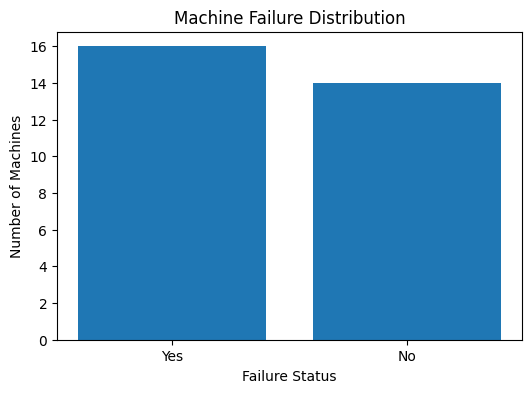

Average Temperature by Failure Status:
Failure
No     67.50
Yes    90.75
Name: Temperature_C, dtype: float64
Average Vibration Level by Failure Status:
Failure
No     2.2500
Yes    4.8875
Name: Vibration_Level, dtype: float64
Average Pressure by Failure Status:
Failure
No      96.000
Yes    134.625
Name: Pressure_psi, dtype: float64


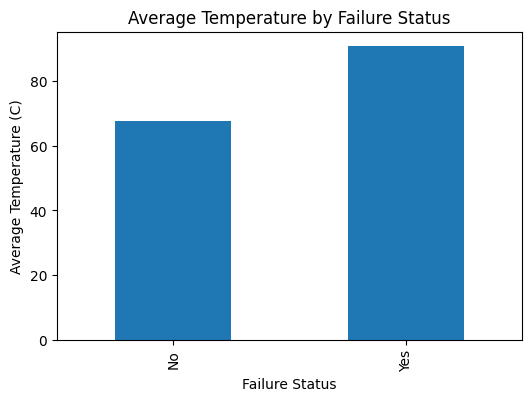

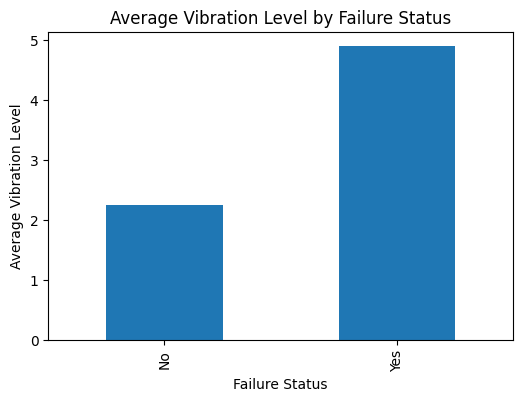

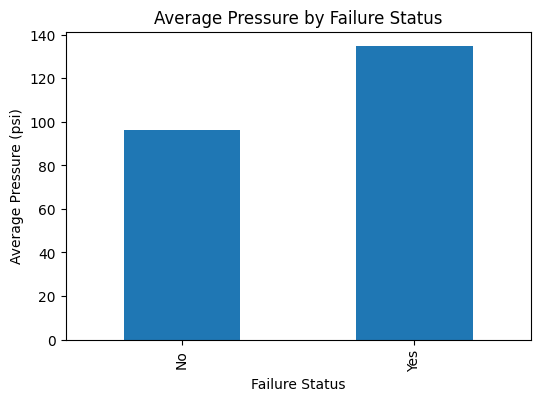

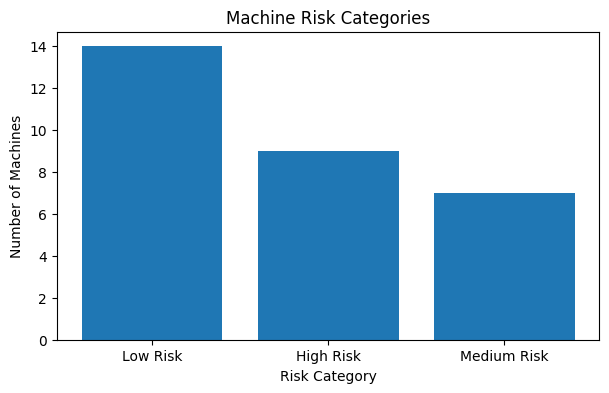

Features:
   Machine_Type_Encoded  Operating_Hours  Temperature_C  Vibration_Level  \
0                     1             1200             78              3.2   
1                     3              800             65              2.1   
2                     2             1500             88              4.8   
3                     1              500             60              1.8   
4                     3              900             70              2.5   

   Pressure_psi  Humidity_Percent  Error_Count_Last_30_Days  \
0           110                40                         2   
1            95                35                         0   
2           130                55                         5   
3            90                30                         0   
4           100                38                         1   

   Maintenance_History_Encoded  
0                            1  
1                            1  
2                            0  
3                     

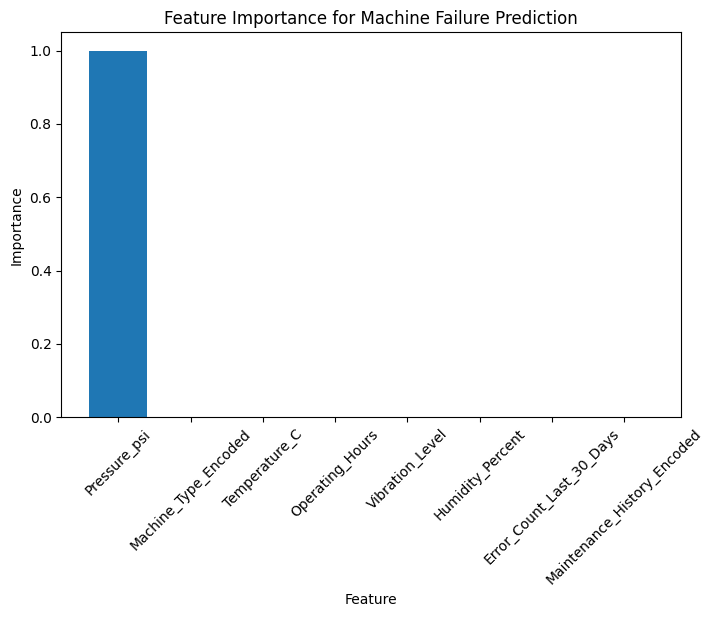

Prediction: This machine is likely to fail soon and needs maintenance.
Total Machines: 30
Machines Likely Failed: 16
Machines Not Failed: 14
High Risk Machines: 9
Most Common Maintenance Action: Normal Monitoring
Top Failure Driver: Pressure_psi


In [1]:
# Cell 1
# Import all required libraries for data handling, visualization,
# preprocessing, machine learning, and model evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Cell 2: Create the predictive maintenance dataset
# Cell 2
# Create a sample predictive maintenance dataset
# Each row represents one machine and its operational condition

data = {
    "Machine_ID": ["M001", "M002", "M003", "M004", "M005", "M006", "M007", "M008", "M009", "M010",
                   "M011", "M012", "M013", "M014", "M015", "M016", "M017", "M018", "M019", "M020",
                   "M021", "M022", "M023", "M024", "M025", "M026", "M027", "M028", "M029", "M030"],

    "Machine_Type": ["Compressor", "Pump", "Conveyor", "Compressor", "Pump", "Boiler", "Conveyor", "Pump", "Boiler", "Compressor",
                     "Pump", "Conveyor", "Boiler", "Compressor", "Pump", "Boiler", "Conveyor", "Pump", "Compressor", "Boiler",
                     "Pump", "Conveyor", "Boiler", "Compressor", "Pump", "Conveyor", "Boiler", "Pump", "Compressor", "Boiler"],

    "Operating_Hours": [1200, 800, 1500, 500, 900, 1800, 1100, 700, 1700, 600,
                        950, 1300, 1600, 550, 880, 1900, 1250, 720, 1400, 1750,
                        990, 1350, 1650, 580, 910, 1450, 1850, 760, 1550, 1720],

    "Temperature_C": [78, 65, 88, 60, 70, 96, 82, 68, 94, 62,
                      72, 85, 92, 61, 69, 98, 84, 67, 87, 95,
                      73, 86, 93, 63, 71, 89, 97, 66, 90, 96],

    "Vibration_Level": [3.2, 2.1, 4.8, 1.8, 2.5, 5.5, 3.9, 2.0, 5.2, 1.9,
                        2.6, 4.1, 5.0, 1.7, 2.4, 5.8, 4.0, 2.2, 4.6, 5.3,
                        2.7, 4.3, 5.1, 1.8, 2.5, 4.7, 5.6, 2.1, 4.9, 5.4],

    "Pressure_psi": [110, 95, 130, 90, 100, 145, 120, 92, 140, 88,
                     102, 125, 138, 89, 98, 148, 122, 94, 128, 142,
                     103, 126, 139, 91, 99, 129, 146, 93, 132, 144],

    "Humidity_Percent": [40, 35, 55, 30, 38, 60, 45, 33, 58, 31,
                         37, 50, 57, 32, 36, 62, 46, 34, 53, 59,
                         39, 51, 56, 30, 37, 54, 61, 35, 55, 60],

    "Error_Count_Last_30_Days": [2, 0, 5, 0, 1, 7, 3, 0, 6, 0,
                                 1, 4, 6, 0, 1, 8, 3, 0, 5, 7,
                                 1, 4, 6, 0, 1, 5, 8, 0, 6, 7],

    "Maintenance_History": ["Recent", "Recent", "Old", "Recent", "Recent", "Old", "Old", "Recent", "Old", "Recent",
                            "Recent", "Old", "Old", "Recent", "Recent", "Old", "Old", "Recent", "Old", "Old",
                            "Recent", "Old", "Old", "Recent", "Recent", "Old", "Old", "Recent", "Old", "Old"],

    "Failure": ["No", "No", "Yes", "No", "No", "Yes", "Yes", "No", "Yes", "No",
                "No", "Yes", "Yes", "No", "No", "Yes", "Yes", "No", "Yes", "Yes",
                "No", "Yes", "Yes", "No", "No", "Yes", "Yes", "No", "Yes", "Yes"]
}

df = pd.DataFrame(data)

# Display first 5 rows of the dataset
df.head()


# Cell 3: View the full dataset
# Cell 3
# Display the complete predictive maintenance dataset

df


# Cell 4: Check dataset information
# Cell 4
# Check column names, data types, and non-null values

df.info()


# Cell 5: Check for missing values
# Cell 5
# Verify if there are any missing values in the dataset

df.isnull().sum()


# Cell 6: Basic statistical summary
# Cell 6
# Generate summary statistics for numeric columns

df.describe()


# Cell 7: Analyze machine failure count
# Cell 7
# Count how many machines failed and how many did not fail

df["Failure"].value_counts()


# Cell 8: Visualize machine failure distribution
# Cell 8
# Plot failure distribution

failure_counts = df["Failure"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(failure_counts.index, failure_counts.values)
plt.title("Machine Failure Distribution")
plt.xlabel("Failure Status")
plt.ylabel("Number of Machines")
plt.show()


# Cell 9: Calculate average temperature by failure status
# Cell 9
# Compare average machine temperature for failed and non-failed machines

avg_temp_by_failure = df.groupby("Failure")["Temperature_C"].mean()

print("Average Temperature by Failure Status:")
print(avg_temp_by_failure)


# Cell 10: Calculate average vibration by failure status
# Cell 10
# Compare average vibration level for failed and non-failed machines

avg_vibration_by_failure = df.groupby("Failure")["Vibration_Level"].mean()

print("Average Vibration Level by Failure Status:")
print(avg_vibration_by_failure)


# Cell 11: Calculate average pressure by failure status
# Cell 11
# Compare average pressure for failed and non-failed machines

avg_pressure_by_failure = df.groupby("Failure")["Pressure_psi"].mean()

print("Average Pressure by Failure Status:")
print(avg_pressure_by_failure)


# Cell 12: Visualize average temperature by failure
# Cell 12
# Plot average temperature grouped by failure status

avg_temp_by_failure.plot(kind="bar", figsize=(6, 4))
plt.title("Average Temperature by Failure Status")
plt.xlabel("Failure Status")
plt.ylabel("Average Temperature (C)")
plt.show()


# Cell 13: Visualize average vibration by failure
# Cell 13
# Plot average vibration grouped by failure status

avg_vibration_by_failure.plot(kind="bar", figsize=(6, 4))
plt.title("Average Vibration Level by Failure Status")
plt.xlabel("Failure Status")
plt.ylabel("Average Vibration Level")
plt.show()


# Cell 14: Visualize average pressure by failure
# Cell 14
# Plot average pressure grouped by failure status

avg_pressure_by_failure.plot(kind="bar", figsize=(6, 4))
plt.title("Average Pressure by Failure Status")
plt.xlabel("Failure Status")
plt.ylabel("Average Pressure (psi)")
plt.show()


# Cell 15: Create a simple machine risk category
# Cell 15
# Create a business-friendly machine risk category
# High Risk -> high temperature or high vibration or many errors
# Medium Risk -> moderate stress conditions
# Low Risk -> stable condition

def risk_category(row):
    if row["Temperature_C"] >= 90 or row["Vibration_Level"] >= 5.0 or row["Error_Count_Last_30_Days"] >= 6:
        return "High Risk"
    elif row["Temperature_C"] >= 80 or row["Vibration_Level"] >= 4.0 or row["Error_Count_Last_30_Days"] >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Category"] = df.apply(risk_category, axis=1)

# Display updated dataset
df.head()


# Cell 16: Count machines by risk category
# Cell 16
# Count number of machines in each risk category

df["Risk_Category"].value_counts()


# Cell 17: Visualize machine risk categories
# Cell 17
# Plot machine count by risk category

risk_counts = df["Risk_Category"].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Machine Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Machines")
plt.show()


# Cell 18: Identify highest-risk machines
# Cell 18
# Display machines classified as High Risk
# These should be inspected first by the maintenance team

df[df["Risk_Category"] == "High Risk"]


# Cell 19: Encode categorical columns
# Cell 19
# Convert categorical text columns into numeric values
# This is required for machine learning

le_machine_type = LabelEncoder()
le_maintenance = LabelEncoder()
le_failure = LabelEncoder()

df["Machine_Type_Encoded"] = le_machine_type.fit_transform(df["Machine_Type"])
df["Maintenance_History_Encoded"] = le_maintenance.fit_transform(df["Maintenance_History"])
df["Failure_Encoded"] = le_failure.fit_transform(df["Failure"])

# Display updated dataset
df.head()


# Cell 20: Select features and target
# Cell 20
# Define input features (X) and target variable (y)
# Target variable is Failure_Encoded
# 0 = No failure, 1 = Failure

X = df[[
    "Machine_Type_Encoded",
    "Operating_Hours",
    "Temperature_C",
    "Vibration_Level",
    "Pressure_psi",
    "Humidity_Percent",
    "Error_Count_Last_30_Days",
    "Maintenance_History_Encoded"
]]

y = df["Failure_Encoded"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


# Cell 21: Split data into training and testing sets
# Cell 21
# Split data into training and testing sets
# 80% for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


# Cell 22: Train the predictive maintenance model
# Cell 22
# Train a Decision Tree classifier to predict machine failure

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Predictive maintenance model trained successfully.")


# Cell 23: Make predictions on test data
# Cell 23
# Predict machine failure on the test dataset

y_pred = model.predict(X_test)

print("Predicted Failure Values:")
print(y_pred)


# Cell 24: Evaluate model accuracy
# Cell 24
# Calculate accuracy of the predictive maintenance model

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)


# Cell 25: Display confusion matrix
# Cell 25
# Show confusion matrix to compare actual and predicted machine failure

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


# Cell 26: Display classification report
# Cell 26
# Show precision, recall, f1-score, and support

report = classification_report(y_test, y_pred)

print("Classification Report:")
print(report)


# Cell 27: Identify feature importance
# Cell 27
# Check which features are most important in predicting machine failure

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


# Cell 28: Visualize feature importance
# Cell 28
# Plot feature importance to understand key drivers of machine failure

plt.figure(figsize=(8, 5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance for Machine Failure Prediction")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


# Cell 29: Predict failure for a new machine
# Cell 29
# Predict whether a new machine is likely to fail
# Example machine:
# Machine_Type = Boiler
# Operating_Hours = 1800
# Temperature_C = 95
# Vibration_Level = 5.4
# Pressure_psi = 145
# Humidity_Percent = 60
# Error_Count_Last_30_Days = 7
# Maintenance_History = Old

new_machine = pd.DataFrame([{
    "Machine_Type_Encoded": le_machine_type.transform(["Boiler"])[0],
    "Operating_Hours": 1800,
    "Temperature_C": 95,
    "Vibration_Level": 5.4,
    "Pressure_psi": 145,
    "Humidity_Percent": 60,
    "Error_Count_Last_30_Days": 7,
    "Maintenance_History_Encoded": le_maintenance.transform(["Old"])[0]
}])

prediction = model.predict(new_machine)

if prediction[0] == 1:
    print("Prediction: This machine is likely to fail soon and needs maintenance.")
else:
    print("Prediction: This machine is currently stable and less likely to fail.")


# Cell 30: Create maintenance action recommendation
# Cell 30
# Generate a simple maintenance action recommendation based on risk category

def maintenance_action(risk):
    if risk == "High Risk":
        return "Immediate Inspection"
    elif risk == "Medium Risk":
        return "Schedule Maintenance Soon"
    else:
        return "Normal Monitoring"

df["Maintenance_Action"] = df["Risk_Category"].apply(maintenance_action)

# Display updated dataset
df[["Machine_ID", "Risk_Category", "Maintenance_Action"]].head(10)


# Cell 31: Count maintenance actions
# Cell 31
# Count how many machines need each type of maintenance action

df["Maintenance_Action"].value_counts()


# Cell 32: View final predictive maintenance dashboard table
# Cell 32
# Display final important columns for managerial review

df[[
    "Machine_ID",
    "Machine_Type",
    "Operating_Hours",
    "Temperature_C",
    "Vibration_Level",
    "Pressure_psi",
    "Error_Count_Last_30_Days",
    "Maintenance_History",
    "Failure",
    "Risk_Category",
    "Maintenance_Action"
]]


# Cell 33: Print final maintenance insights summary
# Cell 33
# Print a concise maintenance intelligence summary

print("Total Machines:", len(df))
print("Machines Likely Failed:", (df["Failure"] == "Yes").sum())
print("Machines Not Failed:", (df["Failure"] == "No").sum())
print("High Risk Machines:", (df["Risk_Category"] == "High Risk").sum())
print("Most Common Maintenance Action:", df["Maintenance_Action"].mode()[0])
print("Top Failure Driver:", feature_importance.iloc[0]["Feature"])